In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request


downloadind video...
video fetched


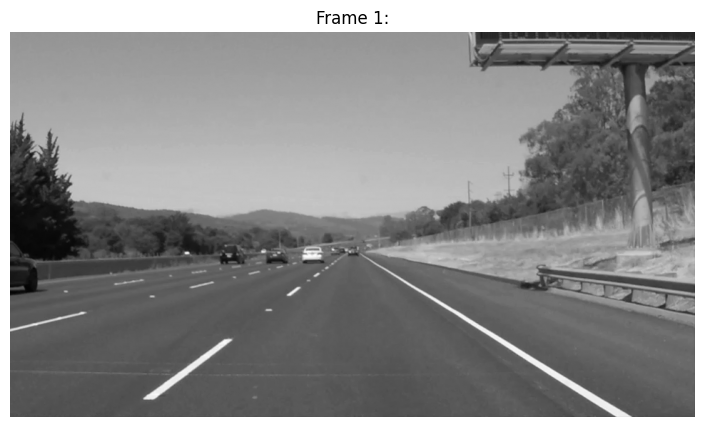

In [6]:


print("downloadind video...")
url = "https://github.com/udacity/CarND-LaneLines-P1/raw/master/test_videos/solidWhiteRight.mp4"
urllib.request.urlretrieve(url, "test_video.mp4")

cap = cv2.VideoCapture("test_video.mp4")

ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

print("video fetched")

plt.figure(figsize=(10, 5))
plt.imshow(gray1, cmap='gray')
plt.title("Frame 1:")
plt.axis('off')
plt.show()

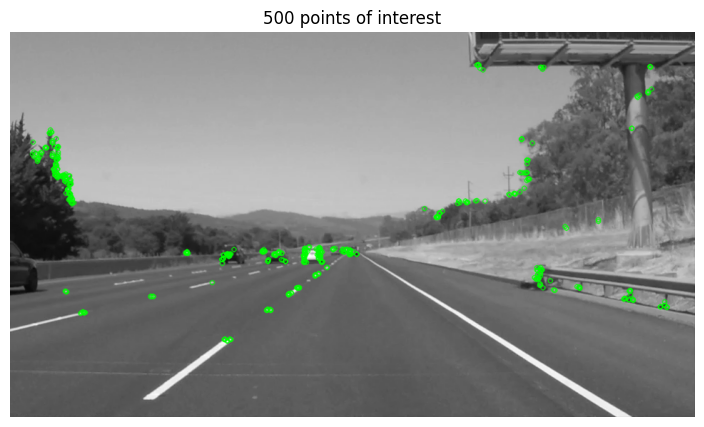

In [7]:

orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

img1_kp = cv2.drawKeypoints(gray1, kp1, None, color=(0, 255, 0), flags=0)

plt.figure(figsize=(10, 5))
plt.imshow(img1_kp)
plt.title(f"{len(kp1)} points of interest")
plt.axis('off')
plt.show()

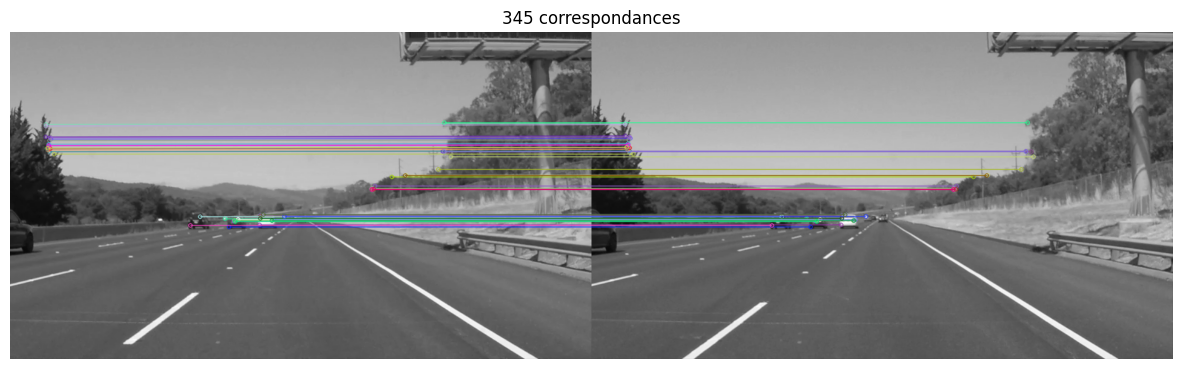

In [8]:

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)
img_matches = cv2.drawMatches(gray1, kp1, gray2, kp2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 7))
plt.imshow(img_matches)
plt.title(f"{len(matches)} correspondances")
plt.axis('off')
plt.show()

Path establishement
220 frames treated 


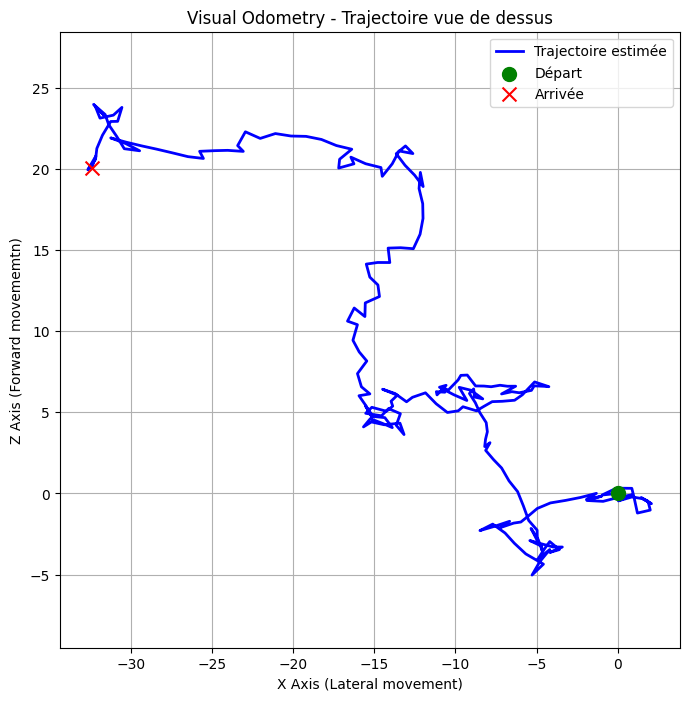

In [9]:

focal = 700.0
pp = (480.0, 270.0)

cap = cv2.VideoCapture("test_video.mp4")
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

R_tot = np.eye(3)
t_tot = np.zeros((3, 1))

traj_x = [0]
traj_z = [0]

orb = cv2.ORB_create(nfeatures=1000)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

print("Path establishement")

frame_count = 0
while cap.isOpened() and frame_count < 300:
    ret, curr_frame = cap.read()
    if not ret:
        break

    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    kp1, des1 = orb.detectAndCompute(prev_gray, None)
    kp2, des2 = orb.detectAndCompute(curr_gray, None)

    if des1 is not None and des2 is not None:
        matches = bf.match(des1, des2)

        matches = sorted(matches, key=lambda x: x.distance)[:100]

        pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
        pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

        if len(pts1) > 5: # Il faut au moins 5 points pour le calcul
            E, mask = cv2.findEssentialMat(pts2, pts1, focal=focal, pp=pp, method=cv2.RANSAC, prob=0.999, threshold=1.0)

            if E is not None and E.shape == (3, 3):
                _, R, t, mask = cv2.recoverPose(E, pts2, pts1, focal=focal, pp=pp)

                t_tot = t_tot + R_tot.dot(t)
                R_tot = R.dot(R_tot)

                traj_x.append(t_tot[0, 0])
                traj_z.append(t_tot[2, 0])

    prev_gray = curr_gray
    frame_count += 1

cap.release()
print(f"{frame_count} frames treated ")

plt.figure(figsize=(8, 8))
plt.plot(traj_x, traj_z, color='blue', linewidth=2, label="Trajectoire estimée")
plt.scatter(traj_x[0], traj_z[0], color='green', marker='o', s=100, label="Départ", zorder=5)
plt.scatter(traj_x[-1], traj_z[-1], color='red', marker='x', s=100, label="Arrivée", zorder=5)

plt.title("Visual Odometry - Trajectoire vue de dessus")
plt.xlabel("X Axis (Lateral movement)")
plt.ylabel("Z Axis (Forward movememtn)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()